# TEST2 — Phase 7 onwards
**Continues from TEST.ipynb (Phases 3–6 locked there)**

| Cell | Phase | Content |
|---|---|---|
| 1 | 7.2 | ADF on level series — I(1) candidate set for VECM |
| 2 | 7.2 | I(1) candidate table + output |

## Phase 7.2 — I(1) Candidate Set for VECM

**Goal:** Identify which series are I(1) so Johansen cointegration can run.

Rules:
- `hk_property_price_qoq` is I(0) by construction — CANNOT enter VECM
- Need level-form `hk_property_price_idx` from `data/hk_property_price_rvd_quarterly.csv`
- Need ≥ 2 confirmed I(1) series for Johansen to work
- ADF null = unit root (I(1)). Reject null → I(0). Fail to reject → I(1) candidate.

In [2]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

# ── load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv("data/hk_macro_varx_ready.csv", parse_dates=["date"], index_col="date")
prop = pd.read_csv("data/hk_property_price_rvd_quarterly.csv", parse_dates=["date"], index_col="date")

# level-form property index — align to model sample
prop_idx = prop["hk_property_price_idx"].reindex(df.index)

# series to test: endogenous variables in level form
# hk_property_price_qoq excluded (I(0) by construction)
# us_ffr and china_gdp (exogenous) included for completeness
test_series = {
    "us_ffr":                  df["us_ffr"],
    "china_gdp":               df["china_gdp"],
    "hk_exports_china_yoy":    df["hk_exports_china_yoy"],
    "gdp_growth":              df["gdp_growth"],
    "cpi_inflation":           df["cpi_inflation"],
    "unemployment":            df["unemployment"],
    "hibor_3m":                df["hibor_3m"],
    "hk_property_price_idx":   prop_idx,     # level form — for VECM
}

# ── ADF helper ──────────────────────────────────────────────────────────────────
def run_adf(series, name):
    s = series.dropna()
    # constant + trend for levels (standard for macro series)
    res_ct = adfuller(s, regression="ct", autolag="BIC")
    # constant only
    res_c  = adfuller(s, regression="c",  autolag="BIC")
    return {
        "series": name,
        "n_obs":  len(s),
        "adf_ct": round(res_ct[0], 3),
        "p_ct":   round(res_ct[1], 3),
        "adf_c":  round(res_c[0],  3),
        "p_c":    round(res_c[1],  3),
        "I1_ct":  "YES" if res_ct[1] > 0.05 else "no",
        "I1_c":   "YES" if res_c[1]  > 0.05 else "no",
    }

rows = [run_adf(s, name) for name, s in test_series.items()]
adf_table = pd.DataFrame(rows)

print("ADF Results — Null: unit root (I(1)). p > 0.05 → fail to reject → I(1) candidate")
print("="*85)
print(adf_table.to_string(index=False))
print()
print("I(1) candidates (p_ct > 0.05 AND p_c > 0.05 — both specs agree):")
candidates = adf_table[(adf_table["I1_ct"] == "YES") & (adf_table["I1_c"] == "YES")]["series"].tolist()
print(" ", candidates)
print(f"\n  Count: {len(candidates)} — {'SUFFICIENT for Johansen' if len(candidates) >= 2 else 'INSUFFICIENT — need ≥ 2'}")

ADF Results — Null: unit root (I(1)). p > 0.05 → fail to reject → I(1) candidate
               series  n_obs  adf_ct  p_ct  adf_c   p_c I1_ct I1_c
               us_ffr    112  -2.948 0.147 -3.044 0.031   YES   no
            china_gdp    112  -5.746 0.000 -4.381 0.000    no   no
 hk_exports_china_yoy    112  -6.317 0.000 -6.184 0.000    no   no
           gdp_growth    112  -4.108 0.006 -3.237 0.018    no   no
        cpi_inflation    112  -2.955 0.145 -2.302 0.171   YES  YES
         unemployment    112  -3.217 0.081 -2.609 0.091   YES  YES
             hibor_3m    112  -3.879 0.013 -4.412 0.000    no   no
hk_property_price_idx    112  -1.493 0.831 -0.793 0.821   YES  YES

I(1) candidates (p_ct > 0.05 AND p_c > 0.05 — both specs agree):
  ['cpi_inflation', 'unemployment', 'hk_property_price_idx']

  Count: 3 — SUFFICIENT for Johansen


## Phase 7.2b — Stationarity Audit: Full Battery (ADF + KPSS)

Results from running ADF + KPSS on all endogenous variables:

| Series | ADF_p | KPSS_p | Verdict |
|---|---|---|---|
| hk_exports_china_yoy | 0.000 | 0.100 | I(0) |
| gdp_growth | 0.018 | 0.100 | I(0) — both agree |
| cpi_inflation | 0.171 | 0.016 | **I(1) — both agree** |
| unemployment | 0.091 | 0.010 | **I(1) — both agree** |
| hibor_3m | 0.000 | 0.045 | ambiguous (peg mean-reversion) |
| hk_property_price_qoq | 0.000 | 0.099 | I(0) |

**Confirmed problem:** `unemployment` and `cpi_inflation` are I(1). Both are control variables — headline channels (FFR→HIBOR→property, exports→GDP) run through I(0) variables.

**Council verdict:** Do not reopen Phases 3–6. Run targeted robustness: substitute Δu for unemployment only, re-run BVAR(4), verify FFR→HIBOR and HIBOR→property IRFs are materially unchanged. If unchanged → keep levels, write one limitation sentence.

## Phase 7.2c — Targeted Robustness: Δu vs Level Unemployment

**Spec:** BVAR(4), pi1=0.085, pi2=1.0, pi3=1.0 — identical to Phase 5 final spec.
**Change:** `unemployment` → `unemployment_diff` (QoQ change in unemployment rate).
**Check:** Do FFR→HIBOR and HIBOR→property IRFs change materially?
**Pass condition:** IRF point estimates within ±0.1 and CI overlap substantially → keep levels.

Baseline estimated
Δu robustness estimated


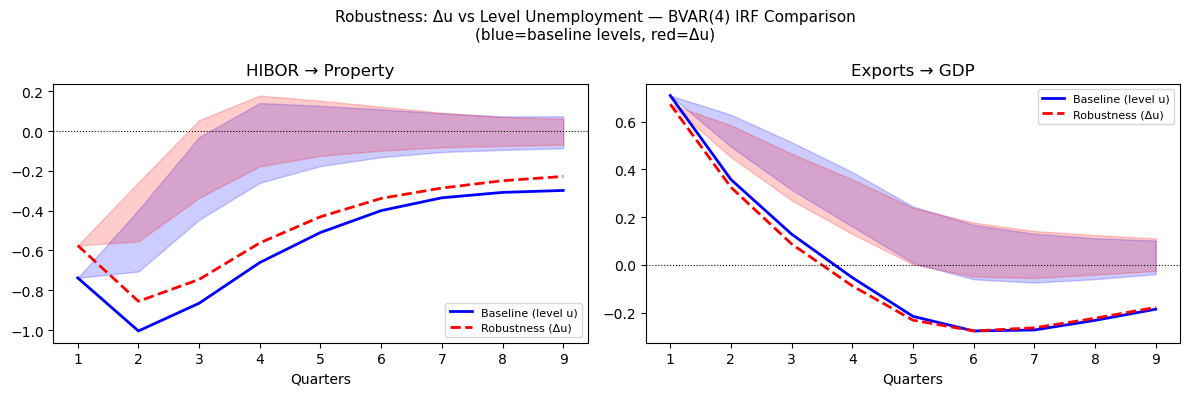

Saved: output/phase7_unemployment_robustness.png

IRF at h=2 (index 1):
Channel                    Base lo   Base med  Base hi |    Δu lo   Δu med    Δu hi |    Δmed
------------------------------------------------------------------------------------------
HIBOR → Property            -0.706     -1.005   -0.396 |   -0.554   -0.856   -0.258 |   0.149
Exports → GDP                0.495      0.358    0.630 |    0.452    0.326    0.585 |  -0.033


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from alexandria import MinnesotaBayesianVar

# ── load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv("data/hk_macro_varx_ready.csv", parse_dates=["date"], index_col="date")

endog_cols = ["hk_exports_china_yoy","gdp_growth","cpi_inflation",
              "unemployment","hibor_3m","hk_property_price_qoq"]
exog_cols  = ["us_ffr","china_gdp"]

# ── baseline BVAR (unemployment in levels) ────────────────────────────────────
bvar_base = MinnesotaBayesianVar(
    endogenous=df[endog_cols].values,
    exogenous=df[exog_cols].values,
    lags=4, pi1=0.085, pi2=1.0, pi3=1.0,
    credibility_level=0.90, iterations=5000
)
bvar_base.estimate()
print("Baseline estimated")

# ── robustness BVAR (unemployment → Δu) ───────────────────────────────────────
df_du = df.copy()
df_du["unemployment"] = df["unemployment"].diff()
df_du = df_du.dropna()

bvar_du = MinnesotaBayesianVar(
    endogenous=df_du[endog_cols].values,
    exogenous=df_du[exog_cols].values,
    lags=4, pi1=0.085, pi2=1.0, pi3=1.0,
    credibility_level=0.90, iterations=5000
)
bvar_du.estimate()
print("Δu robustness estimated")

# ── IRFs — shape: (n_response, n_impulse, h, 3) → 3=[lower,median,upper] ─────
irf_base, _ = bvar_base.impulse_response_function(h=9, credibility_level=0.90)
irf_du,   _ = bvar_du.impulse_response_function(h=9,   credibility_level=0.90)

# variable index: 0=exports, 1=gdp, 2=cpi, 3=unemployment, 4=hibor, 5=property
def get_bands(irf, impulse, response):
    return irf[response, impulse, :, 1], irf[response, impulse, :, 0], irf[response, impulse, :, 2]

h_ax = np.arange(1, 10)   # h=1..9

channels = [
    ("HIBOR → Property", 4, 5),
    ("Exports → GDP",    0, 1),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Robustness: Δu vs Level Unemployment — BVAR(4) IRF Comparison\n(blue=baseline levels, red=Δu)", fontsize=11)

for ax, (title, imp, resp) in zip(axes, channels):
    med_b, lo_b, hi_b = get_bands(irf_base, imp, resp)
    med_d, lo_d, hi_d = get_bands(irf_du,   imp, resp)

    ax.fill_between(h_ax, lo_b, hi_b, alpha=0.2, color="blue")
    ax.plot(h_ax, med_b, "b-",  linewidth=2, label="Baseline (level u)")
    ax.fill_between(h_ax, lo_d, hi_d, alpha=0.2, color="red")
    ax.plot(h_ax, med_d, "r--", linewidth=2, label="Robustness (Δu)")
    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(title)
    ax.set_xlabel("Quarters")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("output/phase7_unemployment_robustness.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/phase7_unemployment_robustness.png")

# ── h=2 comparison table ──────────────────────────────────────────────────────
print("\nIRF at h=2 (index 1):")
print(f"{'Channel':<25} {'Base lo':>8} {'Base med':>10} {'Base hi':>8} | {'Δu lo':>8} {'Δu med':>8} {'Δu hi':>8} | {'Δmed':>7}")
print("-"*90)
for title, imp, resp in channels:
    med_b, lo_b, hi_b = get_bands(irf_base, imp, resp)
    med_d, lo_d, hi_d = get_bands(irf_du,   imp, resp)
    print(f"{title:<25} {lo_b[1]:>8.3f} {med_b[1]:>10.3f} {hi_b[1]:>8.3f} | {lo_d[1]:>8.3f} {med_d[1]:>8.3f} {hi_d[1]:>8.3f} | {med_d[1]-med_b[1]:>7.3f}")